# 🏅 Olympic Games Dataset (1964–2016)

This dataset provides country-level statistics for the Summer Olympic Games from **1964 to 2016**.  
Each row represents one country's participation in a specific Olympic year, including details about its athletes, demographics, and performance.  

## 📊 Columns Explanation

- **team** → The **3-letter IOC country code** (e.g., `USA`, `EGY`, `JPN`).
- **country** → The **full country name** (e.g., `United States`, `Egypt`, `Japan`).
- **year** → The **Olympic year** (e.g., `2008`).
- **events** → The **number of events** in which the country competed that year.
- **athletes** → The **number of athletes** sent by the country.
- **age** → The **average age** of athletes from that country in that year.
- **height** → The **average height (cm)** of athletes from that country in that year.
- **weight** → The **average weight (kg)** of athletes from that country in that year.
- **medals** → The **total number of medals** won by that country in that year.(target)
- **prev_medals** → The **number of medals won in the previous Olympics** (useful for performance trend analysis).
- **prev_3_medals** → The **average number of medals won across the last 3 Olympics**.

## 🎯 Why this dataset is useful?
- To analyze **historical performance trends** of countries.  
- To study **athlete demographics** (age, height, weight) across time.  
- To build **predictive models** (e.g., forecasting medal counts based on past data).  
- To visualize and compare **countries’ Olympic progress**.


In [36]:
import pandas as pd
import numpy as np

In [37]:
df=pd.read_csv('teams.csv')
df.head()

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
0,AFG,Afghanistan,1964,8,8,22.0,161.0,64.2,0,0.0,0.0
1,AFG,Afghanistan,1968,5,5,23.2,170.2,70.0,0,0.0,0.0
2,AFG,Afghanistan,1972,8,8,29.0,168.3,63.8,0,0.0,0.0
3,AFG,Afghanistan,1980,11,11,23.6,168.4,63.2,0,0.0,0.0
4,AFG,Afghanistan,2004,5,5,18.6,170.8,64.8,0,0.0,0.0


In [42]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,2014.0,1995.227408,15.227727,1964.0,1984.0,1996.0,2008.00,2016.0
events,2014.0,36.877855,50.130877,1.0,6.0,14.0,47.00,270.0
athletes,2014.0,76.329692,129.799427,1.0,7.0,21.0,74.75,839.0
age,2014.0,24.812612,2.758258,17.0,23.3,24.7,26.10,66.0
height,2014.0,173.955164,5.262469,151.0,170.6,174.4,177.30,193.0
weight,2014.0,69.328997,7.494740,43.3,64.7,69.5,73.40,148.0
medals,2014.0,10.990070,33.627528,0.0,0.0,0.0,5.00,442.0
prev_medals,2014.0,10.248759,31.951920,0.0,0.0,0.0,4.00,442.0
prev_3_medals,2014.0,9.449901,28.232227,0.0,0.0,0.3,4.65,314.0


# Preprosessing

In [38]:
df.isnull().sum().sort_values(ascending=False)

,0
prev_medals,130
prev_3_medals,130
team,0
year,0
country,0
events,0
athletes,0
height,0
age,0
medals,0


In [39]:
df.dropna(inplace=True)

In [40]:
df.shape

(2014, 11)

In [41]:
df.isnull().sum().sort_values(ascending=False)

,0
team,0
country,0
year,0
events,0
athletes,0
age,0
height,0
weight,0
medals,0
prev_medals,0


# Outliers

In [43]:
def detect_outliers_all(data):
    outlier_summary = {}

    numeric_cols = data.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = data[(data[col] < lower) | (data[col] > upper)]
        outlier_summary[col] = {
            "count": len(outliers),
            "percentage": round(len(outliers) / len(data) * 100, 2),
            "lower_bound": lower,
            "upper_bound": upper
        }

    return pd.DataFrame(outlier_summary).T

# Run function
outlier_report = detect_outliers_all(df)
print(outlier_report)

               count  percentage  lower_bound  upper_bound
year             0.0        0.00     1948.000     2044.000
events         194.0        9.63      -55.500      108.500
athletes       264.0       13.11      -94.625      176.375
age             83.0        4.12       19.100       30.300
height          35.0        1.74      160.550      187.350
weight          50.0        2.48       51.650       86.450
medals         343.0       17.03       -7.500       12.500
prev_medals    351.0       17.43       -6.000       10.000
prev_3_medals  321.0       15.94       -6.975       11.625


# Imbalanced

In [52]:
from sklearn.utils import resample

# Separate the majority and minority classes
df_majority = df[df['medals'] == 0]
df_minority = df[df['medals'] > 0]

# Undersample the majority class
# You can adjust the number of samples to match the size of the minority class or a desired ratio
df_majority_undersampled = resample(df_majority,
                                    replace=False,    # sample without replacement
                                    n_samples=len(df_minority), # match minority class size
                                    random_state=42) # reproducible results

# Combine the undersampled majority class with the minority class
df_balanced = pd.concat([df_majority_undersampled, df_minority])

# Display the new class distribution
print("Distribution of 'medals' after undersampling:")
print(df_balanced['medals'].value_counts())

Distribution of 'medals' after undersampling:
medals
0      840
1      162
2       79
3       57
5       40
      ... 
259      1
242      1
263      1
317      1
248      1
Name: count, Length: 132, dtype: int64


# Visualization

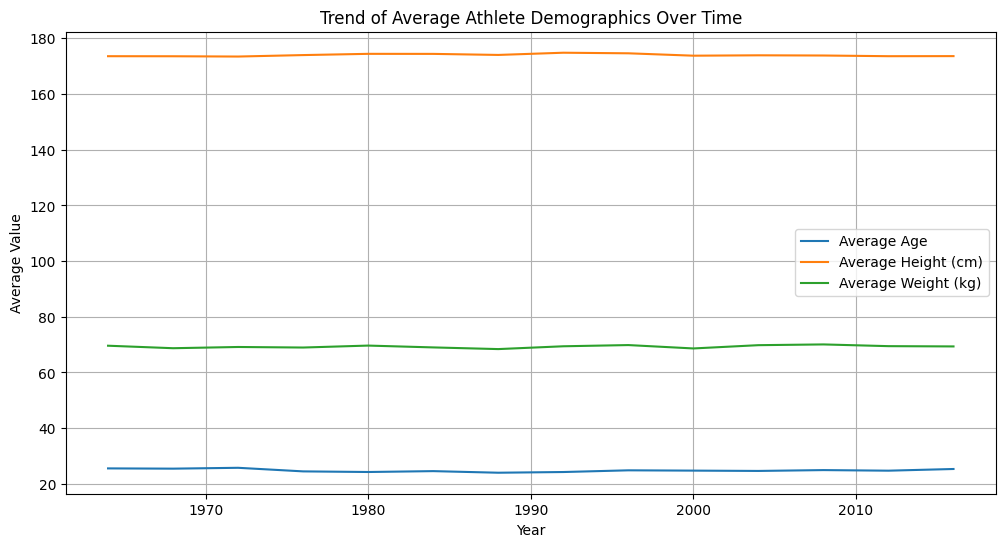

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average age, height, and weight for each year
global_age = df.groupby("year")["age"].mean().reset_index(name="avg_age")
global_h = df.groupby("year")["height"].mean().reset_index(name="avg_height")
global_w = df.groupby("year")["weight"].mean().reset_index(name="avg_weight")

# Create the plot
plt.figure(figsize=(12, 6))
sns.lineplot(x="year", y="avg_age", data=global_age, label="Average Age")
sns.lineplot(x="year", y="avg_height", data=global_h, label="Average Height (cm)")
sns.lineplot(x="year", y="avg_weight", data=global_w, label="Average Weight (kg)")
plt.title("Trend of Average Athlete Demographics Over Time")
plt.xlabel("Year")
plt.ylabel("Average Value")
plt.legend()
plt.grid(True)
plt.show()

In [45]:
print(df.columns)

Index(['team', 'country', 'year', 'events', 'athletes', 'age', 'height',
       'weight', 'medals', 'prev_medals', 'prev_3_medals'],
      dtype='object')


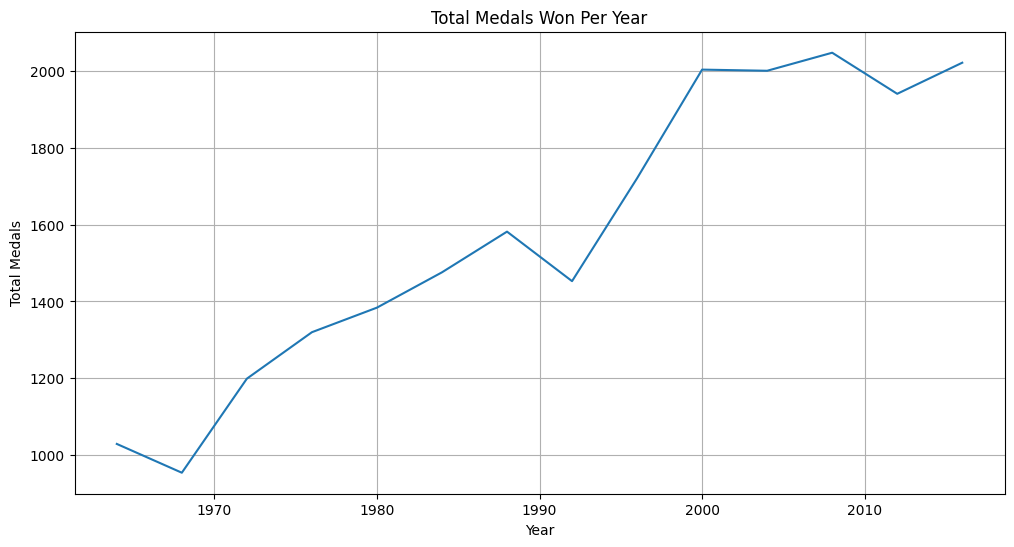

In [46]:
# Calculate the total number of medals won each year
total_medals_by_year = df.groupby("year")["medals"].sum().reset_index(name="total_medals")

# Create the plot
plt.figure(figsize=(12, 6))
sns.lineplot(x="year", y="total_medals", data=total_medals_by_year)
plt.title("Total Medals Won Per Year")
plt.xlabel("Year")
plt.ylabel("Total Medals")
plt.grid(True)
plt.show()

In [47]:
df['medals'].value_counts()

,count
medals,
0,1174
1,162
2,79
3,57
5,40
...,...
259,1
242,1
263,1


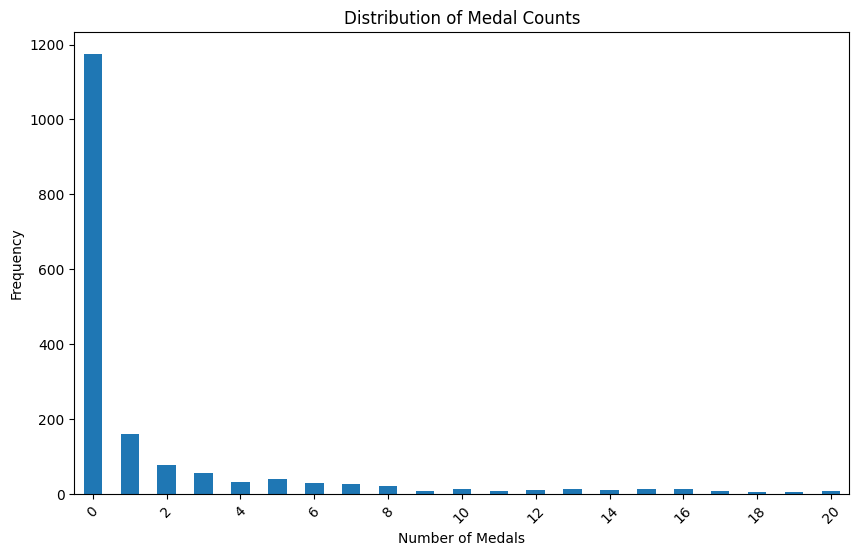

In [51]:
plt.figure(figsize=(10, 6))
df['medals'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Medal Counts")
plt.xlabel("Number of Medals")
plt.ylabel("Frequency")
plt.xlim(-0.5, 20.5) # Set x-axis limits to focus on lower medal counts
plt.xticks(np.arange(0, 21, 2), rotation=45) # Adjust ticks for the new range, e.g., every 2 medals
plt.show()

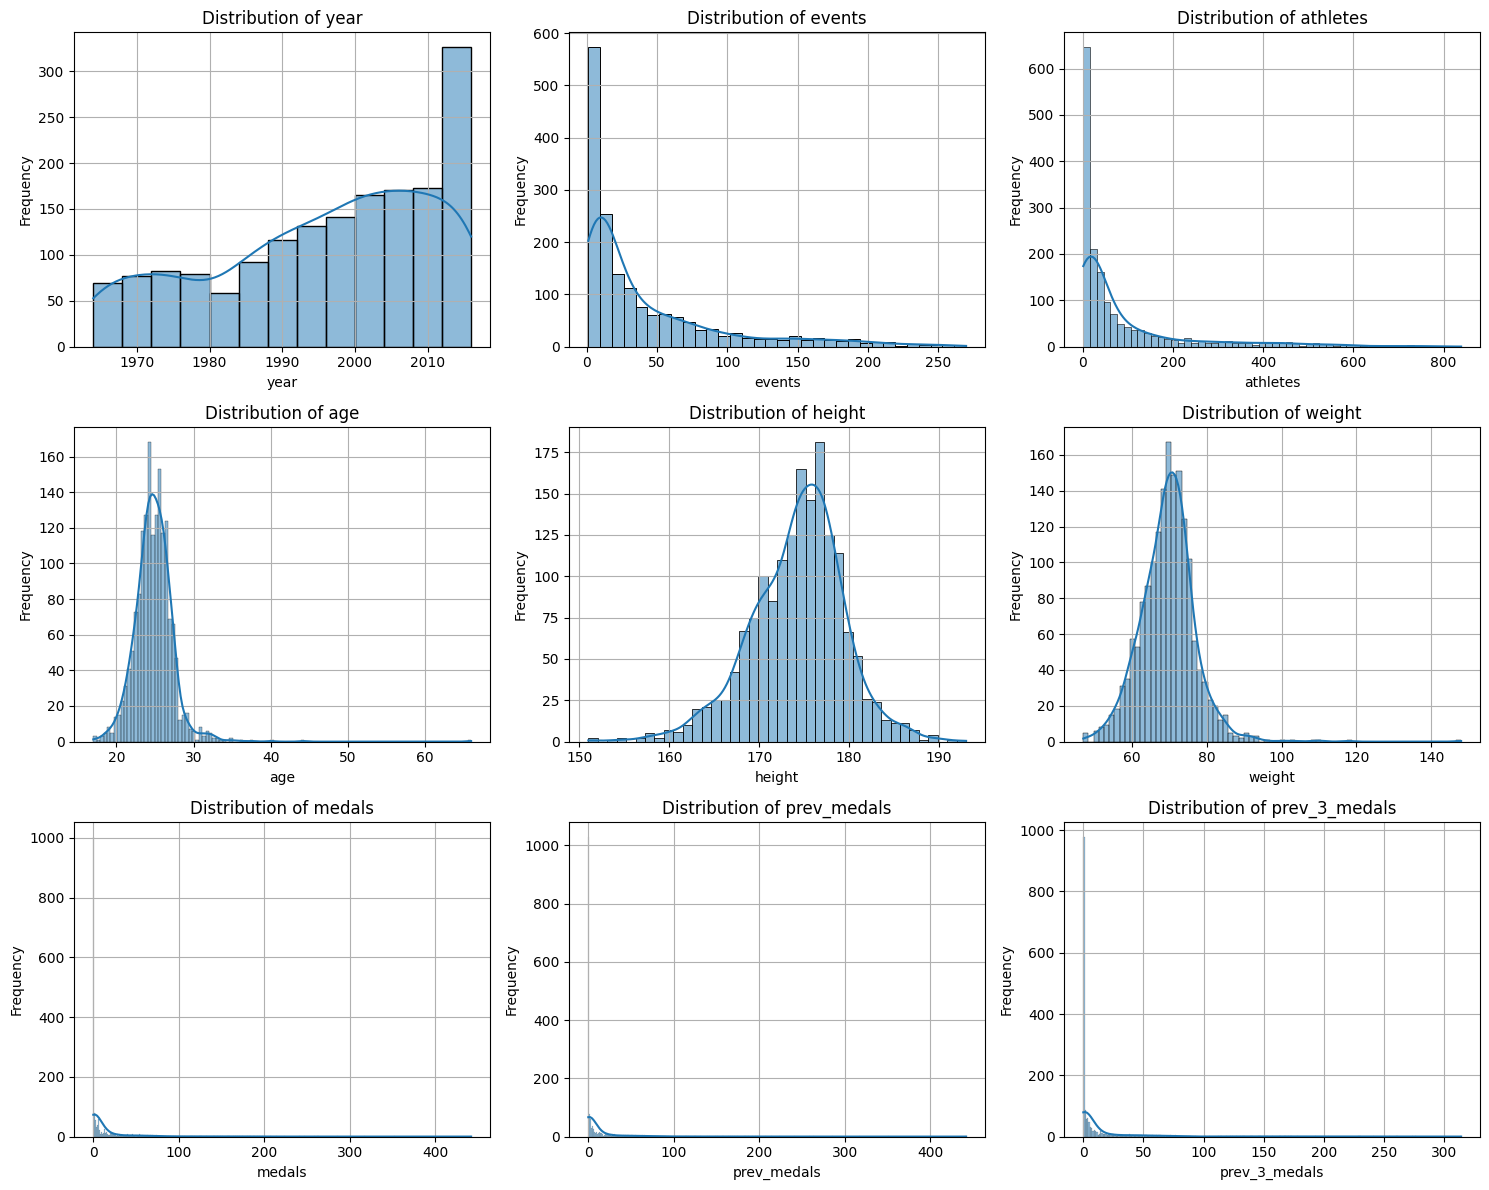

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Get all numerical columns
numeric_cols = df_balanced.select_dtypes(include=['number']).columns.tolist()

# Determine the number of rows and columns for subplots
n_cols = 3  # Number of plots per row
n_rows = math.ceil(len(numeric_cols) / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten() # Flatten the axes array for easy iteration

# Create a histogram for each numerical column
for i, col in enumerate(numeric_cols):
    sns.histplot(data=df_balanced, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Adjust layout to prevent titles overlapping
plt.show()

/tmp/ipython-input-2597640075.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='country', y='medals', data=top_countries, palette='viridis')


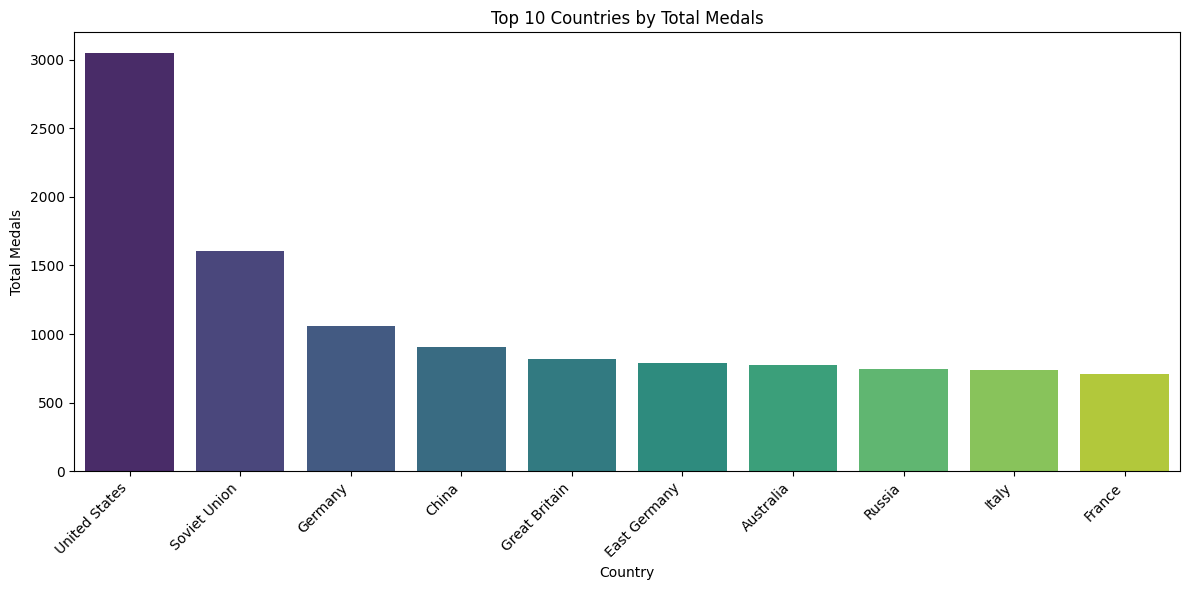

In [54]:
# Group by country and sum the medals
total_medals_by_country = df_balanced.groupby('country')['medals'].sum().reset_index()

# Sort by total medals and get the top N countries
TOP_N = 10  # You can adjust the number of top countries to display
top_countries = total_medals_by_country.sort_values(by='medals', ascending=False).head(TOP_N)

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='country', y='medals', data=top_countries, palette='viridis')
plt.title(f'Top {TOP_N} Countries by Total Medals')
plt.xlabel('Country')
plt.ylabel('Total Medals')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

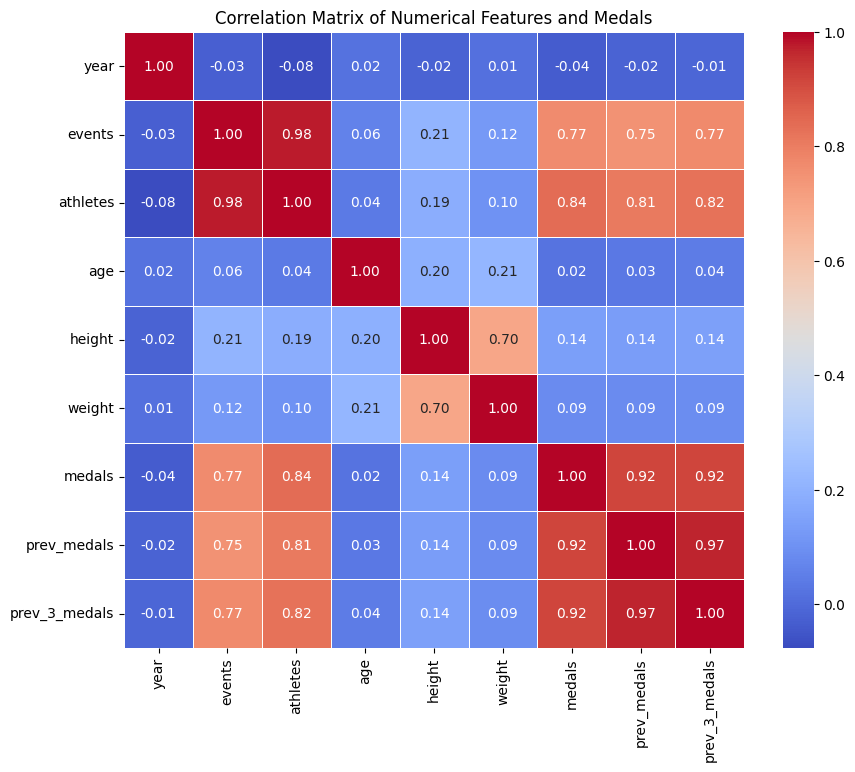

In [55]:
# Calculate the correlation matrix
correlation_matrix = df_balanced.select_dtypes(include=np.number).corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features and Medals')
plt.show()

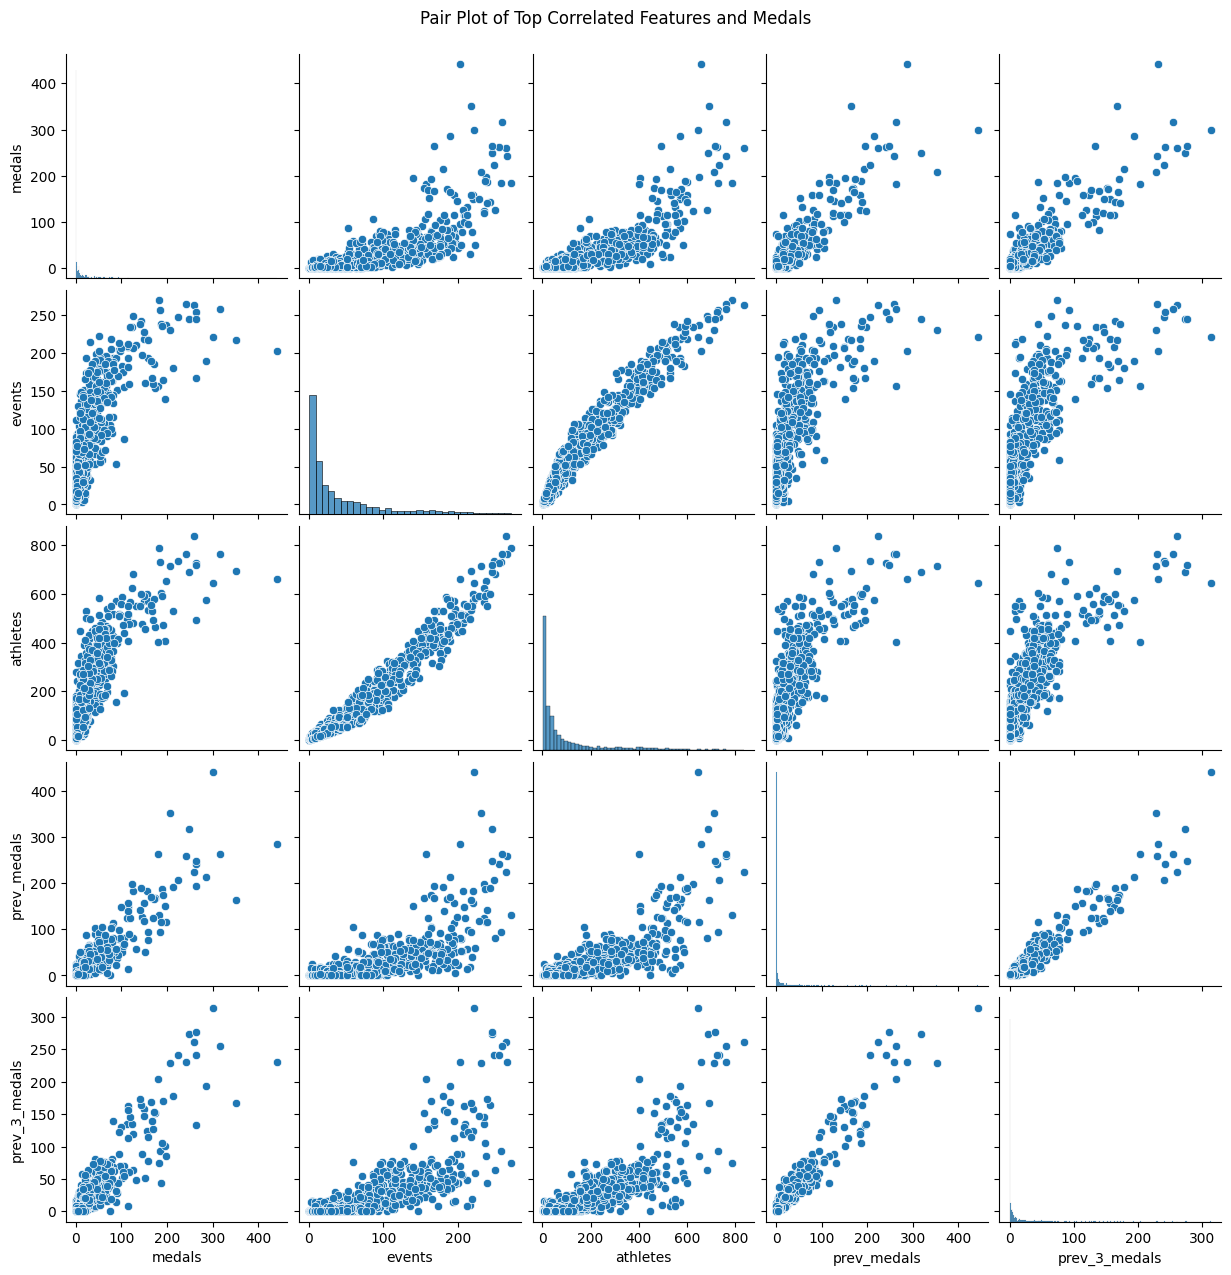

In [56]:
# Features with the highest correlation to 'medals'
top_correlated_features = ['medals', 'events', 'athletes', 'prev_medals', 'prev_3_medals']

# Create a pair plot
sns.pairplot(df_balanced[top_correlated_features])
plt.suptitle('Pair Plot of Top Correlated Features and Medals', y=1.02) # Add a title
plt.show()

# Splitting Train and Test data

In [58]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# For now, using only the scaled numerical features
df_balanced=df_balanced[top_correlated_features]
X = df_balanced.drop('medals', axis=1)
y = df_balanced['medals'] # Use the original 'medals' column as it's the target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80/20 split

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1344, 4)
Shape of X_test: (336, 4)
Shape of y_train: (1344,)
Shape of y_test: (336,)


# Normalization

In [59]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Select only the numerical columns from the balanced dataframe
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the numerical columns
scaled_data = scaler.fit_transform(df_balanced[numeric_cols])

# Create a new DataFrame with the scaled data
df_scaled = pd.DataFrame(scaled_data, columns=numeric_cols)

# Display the first few rows of the scaled DataFrame
print("Scaled DataFrame:")
display(df_scaled.head())

Scaled DataFrame:


,events,athletes,prev_medals,prev_3_medals
0,-0.757312,-0.603604,-0.353456,-0.368862
1,-0.700816,-0.603604,-0.353456,-0.368862
2,-0.568990,-0.444889,-0.353456,-0.368862
3,-0.606655,-0.545889,-0.353456,-0.368862
4,-0.757312,-0.625247,-0.353456,-0.368862


# Training and Grid Search

In [61]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

# Define the parameter grid to search
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'gamma': ['scale', 'auto', 0.1, 1], # Kernel coefficient
    'kernel': ['linear', 'rbf'] # Kernel type
}

# Initialize the SVR model
svm_model = SVR()

# Initialize GridSearchCV
# We'll use the training data without the non-numerical columns
grid_search = GridSearchCV(svm_model, param_grid, cv=5, scoring='neg_mean_squared_error') # Using negative MSE as scoring

# Fit GridSearchCV to find the best parameters
# X_train already contains only numerical columns
grid_search.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score (negative MSE): ", grid_search.best_score_)

# Get the best model
best_svm_model = grid_search.best_estimator_

Best parameters found:  {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation score (negative MSE):  -197.51623044866093


In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Drop non-numerical columns from X_test before making predictions
# X_test already contains only numerical columns, so this line is not needed
# X_test_numeric = X_test.drop(['team', 'country'], axis=1)

# Make predictions on the test data using the best_svm_model
y_pred = best_svm_model.predict(X_test) # Use X_test directly as it's already numerical

# Evaluate the model's performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Calculate RMSE by taking the square root of MSE
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Display the first few predictions and actual values for comparison
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nFirst 10 Actual vs Predicted Medals:")
display(results_df.head(10))

Mean Absolute Error (MAE): 4.09
Mean Squared Error (MSE): 98.97
Root Mean Squared Error (RMSE): 9.95
R-squared (R2): 0.91

First 10 Actual vs Predicted Medals:


,Actual,Predicted
1974,1,0.570162
1803,0,0.019256
644,0,0.207734
1403,0,-0.018131
282,40,40.951369
174,0,0.130860
2113,15,22.189879
1110,1,0.163880
2015,1,-0.064866
940,0,0.170588
